In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-05-17 19:17:43.095323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779045463.290315      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779045463.342907      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779045463.831208      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779045463.831247      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779045463.831250      57 computation_placer.cc:177] computation placer alr

In [2]:
train_data = r"/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Train_Alphabet"
train_data_generator = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)
train_gen = train_data_generator.flow_from_directory(
    train_data,
    target_size=(64, 64),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    subset='training'
)
val_generator = train_data_generator.flow_from_directory(
    train_data,
    target_size=(64, 64),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    subset='validation',
    shuffle=False
)

Found 19440 images belonging to 27 classes.
Found 4860 images belonging to 27 classes.


In [3]:
model = Sequential()
model.add(Conv2D(32, (3,3), input_shape = (64, 64, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(train_gen.num_classes, activation = 'softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779045498.769053      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779045498.775283      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,011 (4.89 MB)

 Trainable params: 1,281,051 (4.89 MB)

 Non-trainable params: 960 (3.75 KB)

In [4]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True,    
    verbose = 1
) 

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    patience = 2,
    factor = 0.3,
    min_lr = 1e-6,
    verbose = 1
) 


training_res = model.fit(
          train_gen,
          validation_data = val_generator,
          callbacks = [early_stopping, reduce_lr],
          epochs=25,
          verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1779045506.219185     143 service.cc:152] XLA service 0x7cd430002550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779045506.219242     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779045506.219250     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779045506.831444     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/304 ━━━━━━━━━━━━━━━━━━━━ 44:18 9s/step - accuracy: 0.0156 - loss: 4.3401

I0000 00:00:1779045511.216640     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


304/304 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.1570 - loss: 3.1379 - val_accuracy: 0.0374 - val_loss: 5.0448 - learning_rate: 0.0010
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 252s 829ms/step - accuracy: 0.5312 - loss: 1.5157 - val_accuracy: 0.5280 - val_loss: 1.4735 - learning_rate: 0.0010
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 250s 824ms/step - accuracy: 0.7041 - loss: 0.9625 - val_accuracy: 0.7846 - val_loss: 0.7149 - learning_rate: 0.0010
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 250s 824ms/step - accuracy: 0.7935 - loss: 0.6771 - val_accuracy: 0.8014 - val_loss: 0.6579 - learning_rate: 0.0010
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 249s 818ms/step - accuracy: 0.8410 - loss: 0.5217 - val_accuracy: 0.8547 - val_loss: 0.4967 - learning_rate: 0.0010
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 252s 831ms/step - accuracy: 0.8675 - loss: 0.4393 - val_accuracy: 0.9074 - val_loss: 0.3331 - learning_rate: 0.0010
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 256s 843ms/step - accuracy: 0.8861 - l

In [5]:
import numpy as np

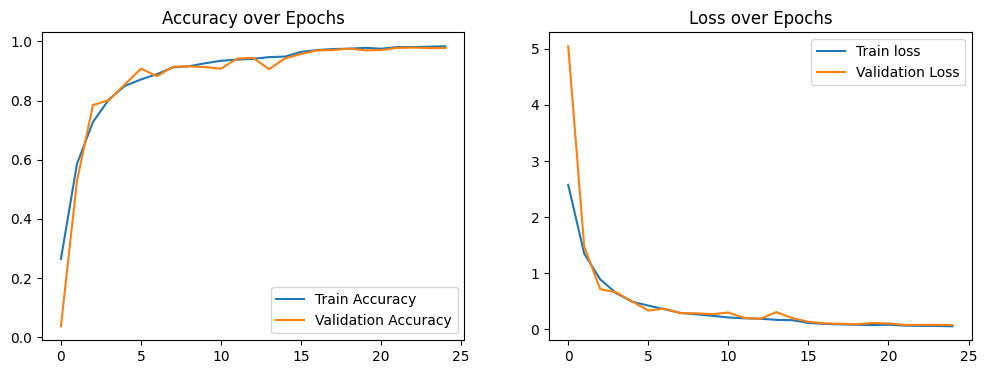

76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 670ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       180
           1       1.00      0.97      0.99       180
           2       0.98      0.96      0.97       180
           3       1.00      0.99      1.00       180
           4       0.97      0.96      0.96       180
           5       0.98      0.98      0.98       180
           6       0.97      0.99      0.98       180
           7       0.98      0.97      0.97       180
           8       0.98      0.99      0.98       180
           9       0.98      0.98      0.98       180
          10       0.96      0.98      0.97       180
          11       0.99      0.98      0.99       180
          12       0.99      0.99      0.99       180
          13       0.94      0.99      0.96       180
          14       0.98      0.96      0.97       180
          15       0.98      0.98      0.98       180
          16       0.97      0.99      

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(training_res.history['accuracy'], label='Train Accuracy')
plt.plot(training_res.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(training_res.history['loss'], label='Train loss')
plt.plot(training_res.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

val_generator.reset()
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes
print(classification_report(y_true, y_pred))

Found 2700 images belonging to 27 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 579ms/step - accuracy: 0.9897 - loss: 0.0438
Final Test Accuracy: 98.78%

Final loss: 4.26%

43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 577ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       1.00      0.99      0.99       100
           2       0.99      0.98      0.98       100
           3       1.00      1.00      1.00       100
           4       0.98      1.00      0.99       100
           5       0.99      1.00      1.00       100
           6       0.97      1.00      0.99       100
           7       1.00      0.99      0.99       100
           8       1.00      0.99      0.99       100
           9       0.99      1.00      1.00       100
          10       0.99      0.99      0.99       100
          11       0.99      0.99      0.99       100
          12       1.00      0.99      0.99       100
          13       0.95      0.96      0.96       100
          14       0.94

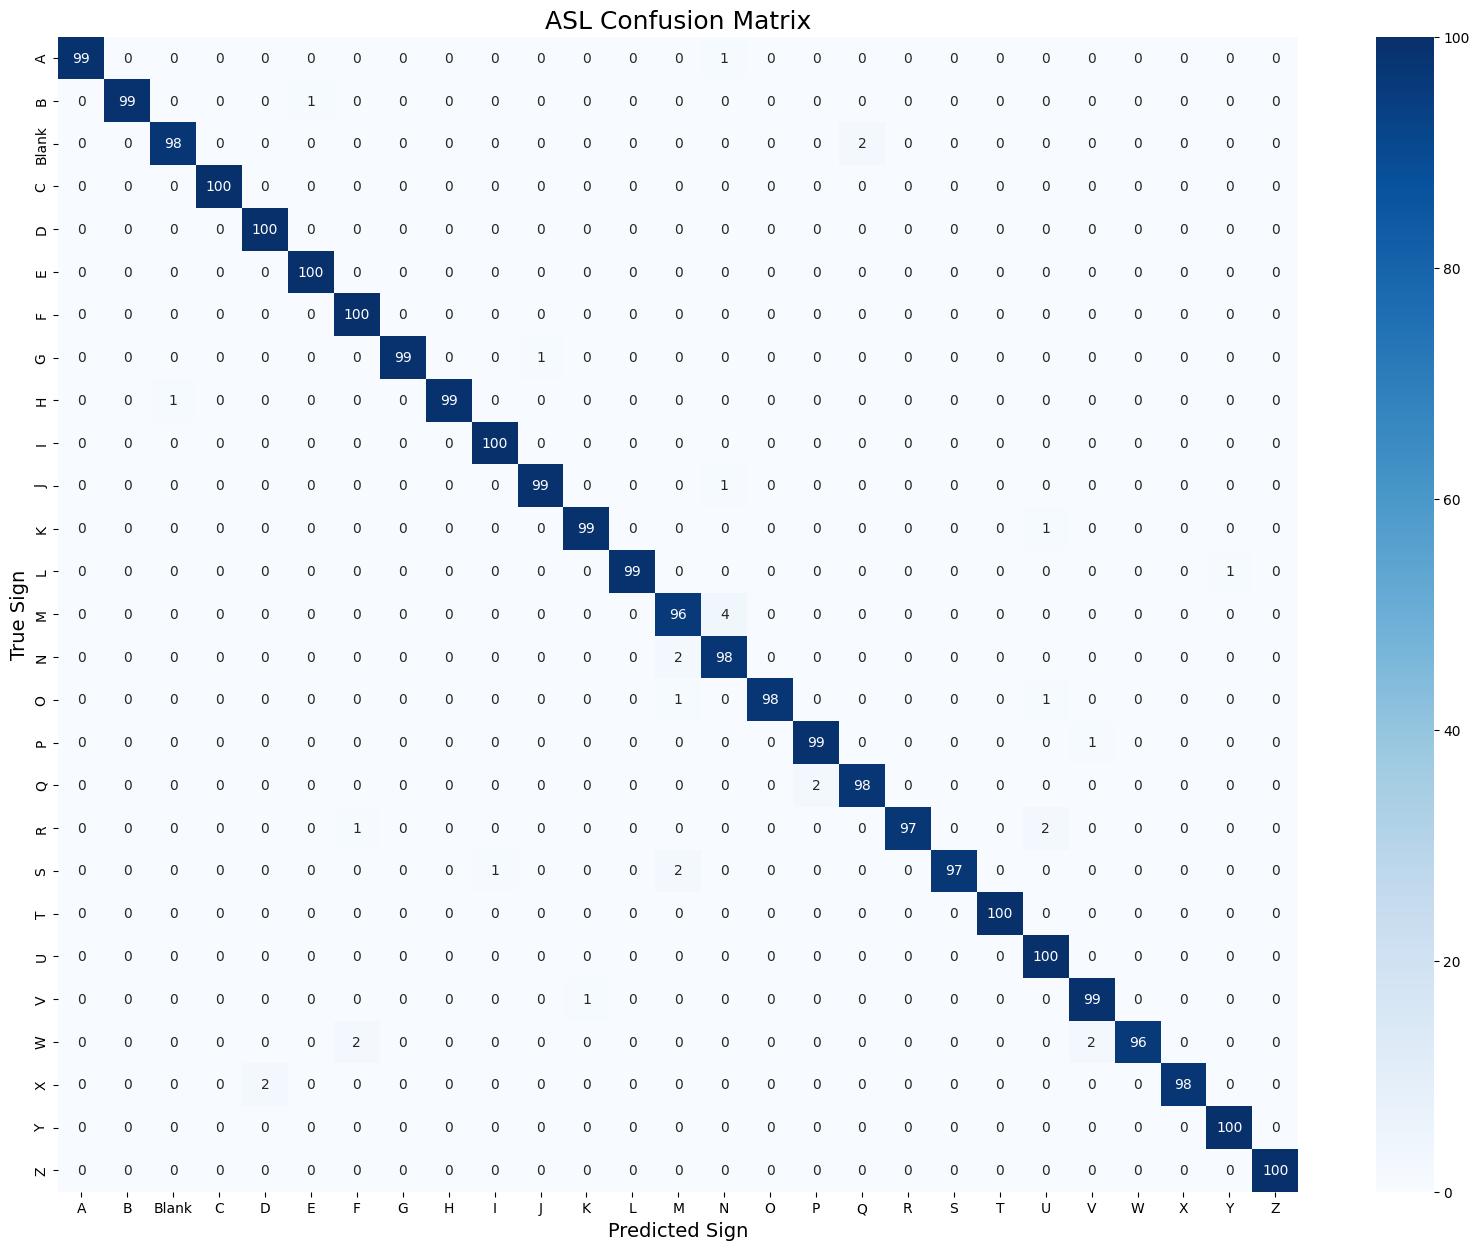

In [10]:
#Testing Model on Test data
test_data = '/kaggle/input/datasets/lexset/synthetic-asl-alphabet/Test_Alphabet'
test_data_generator = ImageDataGenerator(rescale = 1./255)
test_gen = test_data_generator.flow_from_directory(
    test_data,
    target_size=(64, 64),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=64,
    shuffle= False
)
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%\n")
print(f"Final loss: {test_loss*100:.2f}%\n")

test_gen.reset()
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred))

class_names = list(test_gen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 15))
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ASL Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Sign', fontsize=14)
plt.ylabel('True Sign', fontsize=14)

plt.show()
